`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model Qwen/Qwen2-0.5B into HookedTransformer


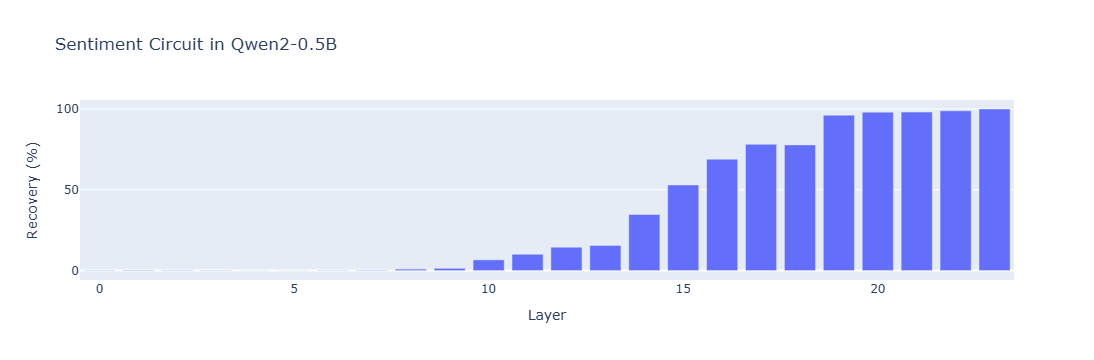

In [1]:
import torch
import plotly.express as px
from transformer_lens import HookedTransformer

# Load model
model = HookedTransformer.from_pretrained("Qwen/Qwen2-0.5B")

# Define prompts and answers (positive vs negative sentiment)
clean_prompt = "I really enjoyed the movie, it was absolutely"
clean_answer = " fantastic"

corrupted_prompt = "I hated the movie, it was absolutely"
corrupted_answer = " terrible"

# Tokenize answers
clean_token = model.to_tokens(clean_answer, prepend_bos=False)[0, 0].item()
corrupted_token = model.to_tokens(corrupted_answer, prepend_bos=False)[0, 0].item()

# Run clean and corrupted baselines
clean_logits, clean_cache = model.run_with_cache(clean_prompt)
corrupted_logits = model(corrupted_prompt)

# Score = logit(clean) - logit(corrupted)
def get_score(logits):
    final = logits[0, -1, :]
    return final[clean_token] - final[corrupted_token]

clean_score = get_score(clean_logits)
corrupted_score = get_score(corrupted_logits)

# Patch each layer's resid_post
n_layers = model.cfg.n_layers
recovery = []

for layer in range(n_layers):
    def patch_hook(act, hook):
        act[:, -1, :] = clean_cache[hook.name][:, -1, :]
        return act

    patched_logits = model.run_with_hooks(
        corrupted_prompt,
        fwd_hooks=[(f"blocks.{layer}.hook_resid_post", patch_hook)]
    )
    patched_score = get_score(patched_logits)
    rec = (patched_score - corrupted_score) / (clean_score - corrupted_score) * 100
    recovery.append(rec.item())

# Plot
fig = px.bar(
    x=list(range(n_layers)),
    y=recovery,
    labels={'x': 'Layer', 'y': 'Recovery (%)'},
    title='Sentiment Circuit in Qwen2-0.5B'
)
fig.show()